In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tuning import Tuner
from strategy import PairsTradingStrategy


In [5]:
# Clean Data

PAIRS = [
    ("V", "MA", "Data/V_daily.csv", "Data/MA_daily.csv"),
    ("PEP", "KO", "Data/PEP_daily.csv", "Data/KO_daily.csv"),
    ("XOM", "CVX", "Data/XOM_daily.csv", "Data/CVX_daily.csv"),
    ("JPM", "BAC", "Data/JPM_daily.csv", "Data/BAC_daily.csv"),
    ("GOOG", "GOOGL", "Data/GOOG_daily.csv", "Data/GOOGL_daily.csv"),
    ("SPY", "IVV", "Data/SPY_daily.csv", "Data/IVV_daily.csv"),
    ("GLD", "IAU", "Data/GLD_daily.csv", "Data/IAU_daily.csv"),
    ("AGG", "BND", "Data/AGG_daily.csv", "Data/BND_daily.csv"),
    ("VTI", "SCHB", "Data/VTI_daily.csv", "Data/VTI_daily.csv"),
]


def load_yfinance_csv(path, ticker):
    asset = pd.read_csv(path)
    asset = asset.iloc[2:].copy()
    asset = asset.rename(columns={"Price": "Date", "Adj Close": ticker})
    asset = asset[["Date", ticker]].copy()
    asset["Date"] = pd.to_datetime(asset["Date"], errors="coerce")
    asset[ticker] = pd.to_numeric(asset[ticker], errors="coerce")
    asset = asset.dropna(subset=["Date", ticker])
    return asset


pair_data = {}

for y_ticker, x_ticker, y_path, x_path in PAIRS:
    y_asset = load_yfinance_csv(y_path, y_ticker)
    x_asset = load_yfinance_csv(x_path, x_ticker)

    pair_df = y_asset.merge(x_asset, on="Date", how="inner")
    pair_df = pair_df.sort_values("Date").reset_index(drop=True)
    pair_df = pair_df[(pair_df[y_ticker] > 0) & (pair_df[x_ticker] > 0)].copy()

    pair_df[f"log_{y_ticker}"] = np.log(pair_df[y_ticker])
    pair_df[f"log_{x_ticker}"] = np.log(pair_df[x_ticker])
    pair_df = pair_df.dropna().reset_index(drop=True)

    pair_data[(y_ticker, x_ticker)] = pair_df

pair_data

{('V',
  'MA'):            Date           V          MA     log_V    log_MA
 0    2008-03-19   12.416173   18.992834  2.519000  2.944062
 1    2008-03-20   14.141251   20.085606  2.649096  3.000003
 2    2008-03-24   13.125982   19.731981  2.574594  2.982241
 3    2008-03-25   13.899518   20.504854  2.631854  3.020662
 4    2008-03-26   14.055548   20.310720  2.643017  3.011149
 ...         ...         ...         ...       ...       ...
 4587 2026-06-12  322.390015  489.980011  5.775762  6.194365
 4588 2026-06-15  323.820007  490.640015  5.780188  6.195711
 4589 2026-06-16  333.119995  501.329987  5.808503  6.217265
 4590 2026-06-17  330.380005  492.989990  5.800244  6.200489
 4591 2026-06-18  327.239990  489.790009  5.790694  6.193977
 
 [4592 rows x 5 columns],
 ('PEP',
  'KO'):             Date         PEP         KO   log_PEP    log_KO
 0     1972-06-01    0.370674   0.287249 -0.992432 -1.247404
 1     1972-06-02    0.369603   0.286163 -0.995326 -1.251192
 2     1972-06-05    0.36

In [6]:
# Backtest PairsTradingStrategy from 2023-01-01 through 2025-12-31

BACKTEST_START = pd.Timestamp("2023-01-01")
BACKTEST_END = pd.Timestamp("2025-12-31")
TRAILING_TUNE_DAYS = 252  # roughly 1 calendar years
MAX_ACTIVE_PAIRS = 5
MIN_TUNE_SHARPE = 0.0
MIN_TUNE_ENTRIES = 5

TRADING_DAYS_PER_YEAR = 252
RISK_FREE_RATE_ANNUAL = 0.04
CAPITAL_BASE = 1.0

trading_dates = sorted(
    set().union(*[
        set(df.loc[(df["Date"] >= BACKTEST_START) & (df["Date"] <= BACKTEST_END), "Date"])
        for df in pair_data.values()
    ])
)

month_starts = pd.Series(trading_dates).groupby(pd.Series(trading_dates).dt.to_period("M")).min().tolist()

monthly_tuning_history = []
daily_decisions = []
strategy = None

for current_date in trading_dates:
    current_date = pd.Timestamp(current_date)

    if current_date in month_starts or strategy is None:
        tune_end_date = current_date - pd.Timedelta(days=1)
        monthly = Tuner.tune_universe(
            pair_data=pair_data,
            pairs=list(pair_data.keys()),
            end_date=tune_end_date,
            trailing_window_days=TRAILING_TUNE_DAYS,
            min_sharpe=MIN_TUNE_SHARPE,
            min_entries=MIN_TUNE_ENTRIES,
            max_pairs=MAX_ACTIVE_PAIRS,
        )

        monthly_tuning_history.append({
            "rebalance_date": current_date,
            "tune_start_date": tune_end_date - pd.DateOffset(days=TRAILING_TUNE_DAYS),
            "tune_end_date": tune_end_date,
            "active_pairs": monthly["active_pairs"],
            "num_active_pairs": len(monthly["active_pairs"]),
            "failures": monthly["failures"],
            "tuned_params": monthly["tuned_params"],
            "all_tuned_params": monthly.get("all_tuned_params", pd.DataFrame()),
        })

        if strategy is None:
            strategy = PairsTradingStrategy(
                pair_data=pair_data,
                tuned_params=monthly["tuned_params"],
                active_pairs=monthly["active_pairs"],
                regime_lookback=252,
                target_spread_vol=0.01,
                max_pair_position=1.0,
                max_gross_exposure=4.0,
                transaction_cost_bps=1.0,
            )
        else:
            strategy.update_tuned_params(monthly["tuned_params"])
            strategy.set_active_pairs(monthly["active_pairs"])

        print(f"{current_date.date()} active pairs: {monthly['active_pairs']}")

    if strategy is None or len(strategy.active_pairs) == 0:
        continue

    day_decisions = strategy.run_day(current_date)
    if not day_decisions.empty:
        daily_decisions.append(day_decisions)

if daily_decisions:
    backtest_trades = pd.concat(daily_decisions, ignore_index=True)
else:
    backtest_trades = pd.DataFrame()

monthly_tuning_summary = pd.DataFrame([
    {
        "rebalance_date": row["rebalance_date"],
        "tune_start_date": row["tune_start_date"],
        "tune_end_date": row["tune_end_date"],
        "num_active_pairs": row["num_active_pairs"],
        "active_pairs": row["active_pairs"],
        "num_failures": len(row["failures"]),
    }
    for row in monthly_tuning_history
])

display(monthly_tuning_summary)
display(backtest_trades.head())


2023-01-03 active pairs: [('V', 'MA'), ('SPY', 'IVV'), ('GLD', 'IAU'), ('PEP', 'KO'), ('AGG', 'BND')]
2023-02-01 active pairs: [('AGG', 'BND'), ('SPY', 'IVV'), ('GLD', 'IAU'), ('XOM', 'CVX'), ('PEP', 'KO')]
2023-03-01 active pairs: [('AGG', 'BND'), ('SPY', 'IVV'), ('GLD', 'IAU'), ('XOM', 'CVX'), ('V', 'MA')]
2023-04-03 active pairs: [('SPY', 'IVV'), ('GLD', 'IAU'), ('V', 'MA'), ('XOM', 'CVX'), ('GOOG', 'GOOGL')]
2023-05-01 active pairs: [('GOOG', 'GOOGL'), ('GLD', 'IAU'), ('XOM', 'CVX'), ('SPY', 'IVV'), ('AGG', 'BND')]
2023-06-01 active pairs: [('SPY', 'IVV'), ('XOM', 'CVX'), ('GOOG', 'GOOGL'), ('GLD', 'IAU'), ('V', 'MA')]
2023-07-03 active pairs: [('SPY', 'IVV'), ('GLD', 'IAU'), ('GOOG', 'GOOGL'), ('AGG', 'BND'), ('XOM', 'CVX')]
2023-08-01 active pairs: [('GLD', 'IAU'), ('SPY', 'IVV'), ('GOOG', 'GOOGL'), ('AGG', 'BND'), ('XOM', 'CVX')]
2023-09-01 active pairs: [('XOM', 'CVX'), ('AGG', 'BND'), ('SPY', 'IVV'), ('GOOG', 'GOOGL'), ('JPM', 'BAC')]
2023-10-02 active pairs: [('SPY', 'IVV'), 

,rebalance_date,tune_start_date,tune_end_date,num_active_pairs,active_pairs,num_failures
0,2023-01-03,2022-04-25,2023-01-02,5,"[(V, MA), (SPY, IVV), (GLD, IAU), (PEP, KO), (...",1
1,2023-02-01,2022-05-24,2023-01-31,5,"[(AGG, BND), (SPY, IVV), (GLD, IAU), (XOM, CVX...",1
2,2023-03-01,2022-06-21,2023-02-28,5,"[(AGG, BND), (SPY, IVV), (GLD, IAU), (XOM, CVX...",1
3,2023-04-03,2022-07-24,2023-04-02,5,"[(SPY, IVV), (GLD, IAU), (V, MA), (XOM, CVX), ...",1
4,2023-05-01,2022-08-21,2023-04-30,5,"[(GOOG, GOOGL), (GLD, IAU), (XOM, CVX), (SPY, ...",1
5,2023-06-01,2022-09-21,2023-05-31,5,"[(SPY, IVV), (XOM, CVX), (GOOG, GOOGL), (GLD, ...",1
6,2023-07-03,2022-10-23,2023-07-02,5,"[(SPY, IVV), (GLD, IAU), (GOOG, GOOGL), (AGG, ...",1
7,2023-08-01,2022-11-21,2023-07-31,5,"[(GLD, IAU), (SPY, IVV), (GOOG, GOOGL), (AGG, ...",1
8,2023-09-01,2022-12-22,2023-08-31,5,"[(XOM, CVX), (AGG, BND), (SPY, IVV), (GOOG, GO...",1
9,2023-10-02,2023-01-22,2023-10-01,5,"[(SPY, IVV), (AGG, BND), (GOOG, GOOGL), (XOM, ...",1


,pair,date,alpha,beta,spread,z,regime_passed,raw_signal,target_position,previous_position,transaction_cost,adf_pvalue,half_life
0,V/MA,2023-01-03,0.606334,0.806711,0.000065,-0.513050,True,1,1.0,0.0,0.0001,0.008943,7.137695
1,SPY/IVV,2023-01-03,-0.003631,1.000319,0.000026,-0.279806,False,0,0.0,0.0,0.0000,0.000539,0.536177
2,GLD/IAU,2023-01-03,1.595282,0.998539,0.000009,0.601937,False,0,0.0,0.0,0.0000,0.501085,NaN
3,PEP/KO,2023-01-03,1.993322,0.762112,-0.000056,0.757289,False,0,0.0,0.0,0.0000,0.543256,NaN
4,AGG/BND,2023-01-03,0.374425,0.981867,0.000140,0.714240,True,0,0.0,0.0,0.0000,0.019914,3.258320


In [7]:
# Compute daily portfolio P&L, excess returns, and performance metrics

if backtest_trades.empty:
    raise ValueError("No trades/decisions were generated. Check tuning filters and data coverage.")

backtest_trades = backtest_trades.sort_values(["pair", "date"]).reset_index(drop=True)
backtest_trades["spread_change"] = backtest_trades.groupby("pair")["spread"].diff()
backtest_trades["gross_pnl"] = backtest_trades["previous_position"] * backtest_trades["spread_change"].fillna(0)
backtest_trades["net_pnl"] = backtest_trades["gross_pnl"] - backtest_trades["transaction_cost"]

portfolio_daily = (
    backtest_trades
    .groupby("date", as_index=False)
    .agg(
        gross_pnl=("gross_pnl", "sum"),
        transaction_cost=("transaction_cost", "sum"),
        net_pnl=("net_pnl", "sum"),
        gross_exposure=("target_position", lambda x: x.abs().sum()),
        active_positions=("target_position", lambda x: x.ne(0).sum()),
        regime_pass_rate=("regime_passed", "mean"),
    )
)
portfolio_daily["gross_return"] = portfolio_daily["gross_pnl"] / CAPITAL_BASE
portfolio_daily["net_return"] = portfolio_daily["net_pnl"] / CAPITAL_BASE
portfolio_daily["risk_free_daily"] = (1 + RISK_FREE_RATE_ANNUAL) ** (1 / TRADING_DAYS_PER_YEAR) - 1
portfolio_daily["gross_excess_return"] = portfolio_daily["gross_return"] - portfolio_daily["risk_free_daily"]
portfolio_daily["net_excess_return"] = portfolio_daily["net_return"] - portfolio_daily["risk_free_daily"]

portfolio_daily["cum_gross_pnl"] = portfolio_daily["gross_pnl"].cumsum()
portfolio_daily["cum_net_pnl"] = portfolio_daily["net_pnl"].cumsum()
portfolio_daily["drawdown"] = portfolio_daily["cum_net_pnl"] - portfolio_daily["cum_net_pnl"].cummax()

gross_vol = portfolio_daily["gross_return"].std()
net_vol = portfolio_daily["net_return"].std()
gross_excess_sharpe = np.nan if gross_vol == 0 or pd.isna(gross_vol) else np.sqrt(TRADING_DAYS_PER_YEAR) * portfolio_daily["gross_excess_return"].mean() / gross_vol
net_excess_sharpe = np.nan if net_vol == 0 or pd.isna(net_vol) else np.sqrt(TRADING_DAYS_PER_YEAR) * portfolio_daily["net_excess_return"].mean() / net_vol

performance_summary = pd.DataFrame([{
    "start_date": portfolio_daily["date"].min(),
    "end_date": portfolio_daily["date"].max(),
    "trading_days": len(portfolio_daily),
    "capital_base": CAPITAL_BASE,
    "risk_free_rate_annual": RISK_FREE_RATE_ANNUAL,
    "risk_free_rate_daily": portfolio_daily["risk_free_daily"].iloc[0],
    "total_gross_pnl": portfolio_daily["gross_pnl"].sum(),
    "total_transaction_cost": portfolio_daily["transaction_cost"].sum(),
    "total_net_pnl": portfolio_daily["net_pnl"].sum(),
    "annual_net_return": portfolio_daily["net_return"].mean() * TRADING_DAYS_PER_YEAR,
    "annual_net_excess_return": portfolio_daily["net_excess_return"].mean() * TRADING_DAYS_PER_YEAR,
    "daily_gross_vol": gross_vol,
    "daily_net_vol": net_vol,
    "gross_excess_sharpe": gross_excess_sharpe,
    "net_excess_sharpe": net_excess_sharpe,
    "max_drawdown": portfolio_daily["drawdown"].min(),
    "avg_gross_exposure": portfolio_daily["gross_exposure"].mean(),
    "avg_active_positions": portfolio_daily["active_positions"].mean(),
    "avg_regime_pass_rate": portfolio_daily["regime_pass_rate"].mean(),
}])

strategy_sharpe = pd.DataFrame([{
    "risk_free_rate_annual": RISK_FREE_RATE_ANNUAL,
    "gross_excess_sharpe": gross_excess_sharpe,
    "net_excess_sharpe": net_excess_sharpe,
}])

print(f"Risk-free rate assumption: {RISK_FREE_RATE_ANNUAL:.2%} annual")
print(f"Strategy gross excess Sharpe: {gross_excess_sharpe:.4f}")
print(f"Strategy net excess Sharpe: {net_excess_sharpe:.4f}")
display(strategy_sharpe.round(6))
display(performance_summary.round(6))
display(portfolio_daily.tail())


Risk-free rate assumption: 4.00% annual
Strategy gross excess Sharpe: 2.9992
Strategy net excess Sharpe: 2.6653


,risk_free_rate_annual,gross_excess_sharpe,net_excess_sharpe
0,0.04,2.999168,2.665348


/var/folders/9r/kw93nskj01zcfj9mqw30j2840000gn/T/ipykernel_40187/3107064624.py:70: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(performance_summary.round(6))


,start_date,end_date,trading_days,capital_base,risk_free_rate_annual,risk_free_rate_daily,total_gross_pnl,total_transaction_cost,total_net_pnl,annual_net_return,annual_net_excess_return,daily_gross_vol,daily_net_vol,gross_excess_sharpe,net_excess_sharpe,max_drawdown,avg_gross_exposure,avg_active_positions,avg_regime_pass_rate
0,2023-01-03,2025-12-31,752,1.0,0.04,0.000156,0.543799,0.050106,0.493693,0.16544,0.126216,0.003004,0.002983,2.999168,2.665348,-0.019116,0.594758,0.597074,0.245745


,date,gross_pnl,transaction_cost,net_pnl,gross_exposure,active_positions,regime_pass_rate,gross_return,net_return,risk_free_daily,gross_excess_return,net_excess_return,cum_gross_pnl,cum_net_pnl,drawdown
747,2025-12-24,0.000363,0.0000,0.000363,1.0,1,0.2,0.000363,0.000363,0.000156,0.000208,0.000208,0.540591,0.490785,0.0000
748,2025-12-26,0.002714,0.0001,0.002614,0.0,0,0.2,0.002714,0.002614,0.000156,0.002558,0.002458,0.543305,0.493399,0.0000
749,2025-12-29,0.000000,0.0001,-0.000100,1.0,1,0.2,0.000000,-0.000100,0.000156,-0.000156,-0.000256,0.543305,0.493299,-0.0001
750,2025-12-30,0.000346,0.0000,0.000346,1.0,1,0.2,0.000346,0.000346,0.000156,0.000191,0.000191,0.543652,0.493645,0.0000
751,2025-12-31,0.000148,0.0001,0.000048,0.0,0,0.2,0.000148,0.000048,0.000156,-0.000008,-0.000108,0.543799,0.493693,0.0000


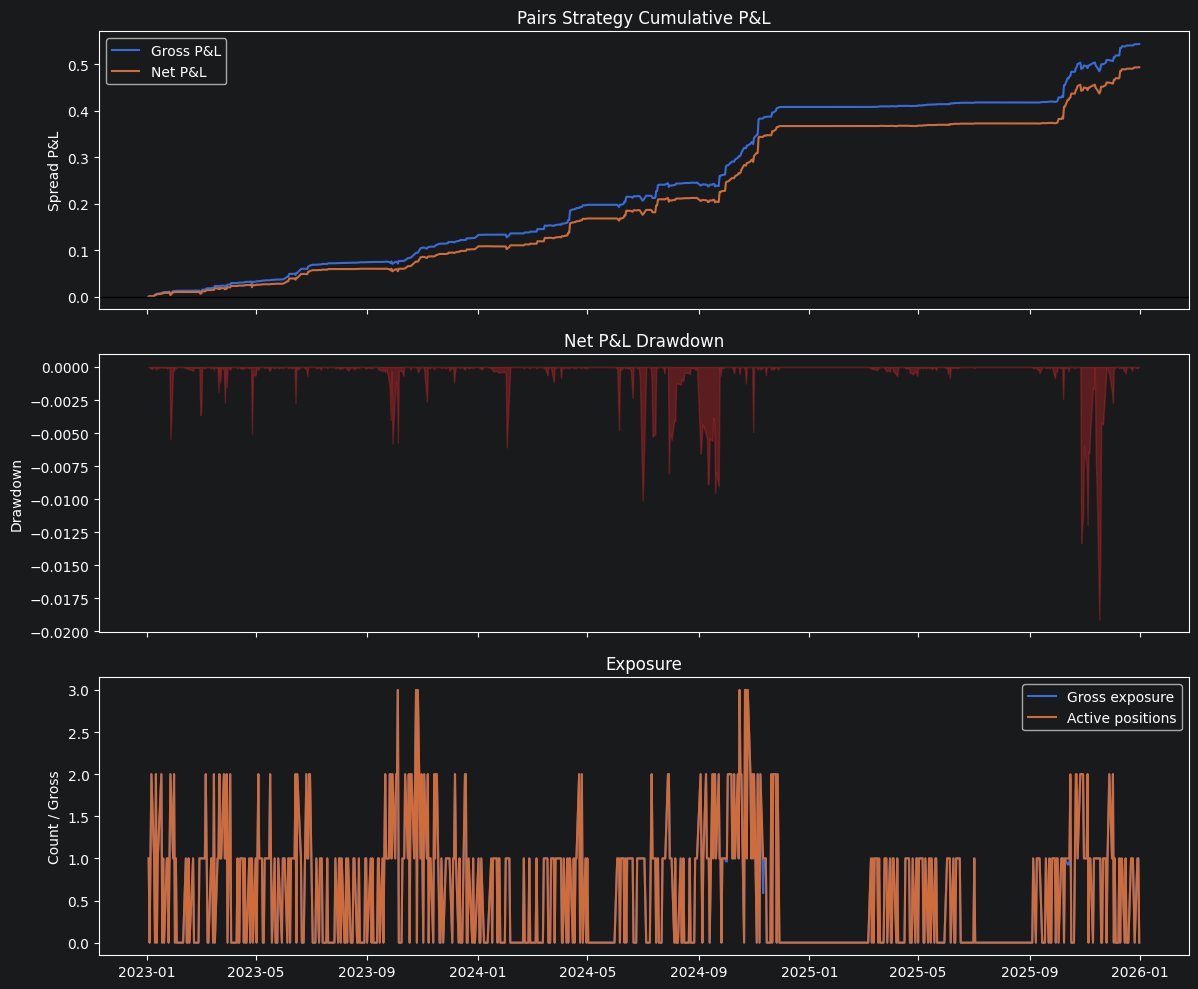

In [8]:
# Plot cumulative P&L, drawdown, and exposure

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(portfolio_daily["date"], portfolio_daily["cum_gross_pnl"], label="Gross P&L")
axes[0].plot(portfolio_daily["date"], portfolio_daily["cum_net_pnl"], label="Net P&L")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Pairs Strategy Cumulative P&L")
axes[0].set_ylabel("Spread P&L")
axes[0].legend()

axes[1].fill_between(portfolio_daily["date"], portfolio_daily["drawdown"], 0, color="tab:red", alpha=0.35)
axes[1].set_title("Net P&L Drawdown")
axes[1].set_ylabel("Drawdown")

axes[2].plot(portfolio_daily["date"], portfolio_daily["gross_exposure"], label="Gross exposure")
axes[2].plot(portfolio_daily["date"], portfolio_daily["active_positions"], label="Active positions")
axes[2].set_title("Exposure")
axes[2].set_ylabel("Count / Gross")
axes[2].legend()

plt.tight_layout()
plt.show()


In [9]:
# Pair-level diagnostics

pair_summary = (
    backtest_trades
    .groupby("pair", as_index=False)
    .agg(
        total_gross_pnl=("gross_pnl", "sum"),
        total_transaction_cost=("transaction_cost", "sum"),
        total_net_pnl=("net_pnl", "sum"),
        avg_abs_position=("target_position", lambda x: x.abs().mean()),
        active_days=("target_position", lambda x: x.ne(0).sum()),
        regime_pass_rate=("regime_passed", "mean"),
        avg_adf_pvalue=("adf_pvalue", "mean"),
        avg_half_life=("half_life", "mean"),
    )
    .sort_values("total_net_pnl", ascending=False)
    .reset_index(drop=True)
)

display(pair_summary.round(6))

active_pair_history = monthly_tuning_summary[["rebalance_date", "num_active_pairs", "active_pairs"]]
print(pair_summary.round(6))
print(active_pair_history)

,pair,total_gross_pnl,total_transaction_cost,total_net_pnl,avg_abs_position,active_days,regime_pass_rate,avg_adf_pvalue,avg_half_life
0,JPM/BAC,0.223673,0.007886,0.215787,0.196422,71,0.400560,0.357803,11.844266
1,V/MA,0.127853,0.009407,0.118445,0.210666,97,0.339130,0.205932,12.040703
2,PEP/KO,0.078693,0.001613,0.077080,0.137464,35,0.192771,0.442293,11.284437
3,XOM/CVX,0.044019,0.003000,0.041019,0.095588,26,0.316176,0.363464,12.162172
4,GOOG/GOOGL,0.061592,0.022200,0.039392,0.296540,180,0.629325,0.069188,3.498961
5,AGG/BND,0.007969,0.006000,0.001969,0.056180,40,0.151685,0.061633,1.399641
6,GLD/IAU,0.000000,0.000000,0.000000,0.000000,0,0.001845,0.150472,0.770728
7,SPY/IVV,0.000000,0.000000,0.000000,0.000000,0,0.000000,0.065639,0.527272


         pair  total_gross_pnl  total_transaction_cost  total_net_pnl  \
0     JPM/BAC         0.223673                0.007886       0.215787   
1        V/MA         0.127853                0.009407       0.118445   
2      PEP/KO         0.078693                0.001613       0.077080   
3     XOM/CVX         0.044019                0.003000       0.041019   
4  GOOG/GOOGL         0.061592                0.022200       0.039392   
5     AGG/BND         0.007969                0.006000       0.001969   
6     GLD/IAU         0.000000                0.000000       0.000000   
7     SPY/IVV         0.000000                0.000000       0.000000   

   avg_abs_position  active_days  regime_pass_rate  avg_adf_pvalue  \
0          0.196422           71          0.400560        0.357803   
1          0.210666           97          0.339130        0.205932   
2          0.137464           35          0.192771        0.442293   
3          0.095588           26          0.316176        0.36